# Ground Truth Visualization for Grid and County Experiments

This notebook visualizes the **true spatially-varying coefficients** (b0, b1, b2) for both experiment types:
- **Grid experiments**: 25×25 regular grid with formulaic DGP
- **County experiments**: US counties with the same formulaic DGP applied to county centroids

This shows what the location encoders and models are trying to learn.

## 1. Import Required Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import our DGP utilities
from dgp_utils import create_grid_data, create_county_data

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Generate Grid Experiment Ground Truth

Generate the 25×25 grid with formulaic DGP (same parameters as experiments).

In [7]:
# Generate grid data (same parameters as gridRun.py)
grid_size = 25
noise_std = 0.1
random_seed = 222

print(f"Generating {grid_size}×{grid_size} grid with noise_std={noise_std}, seed={random_seed}...")
grid_data, grid_extent = create_grid_data(
    size=grid_size,
    coord_system='regional',
    noise_std=noise_std,
    random_seed=random_seed
)

# Sort by lat, lon for consistent reshaping
grid_data = grid_data.sort_values(['lat', 'lon']).reset_index(drop=True)

# Reshape coefficients to grid
b0_grid = grid_data['b0'].values.reshape(grid_size, grid_size)
b1_grid = grid_data['b1'].values.reshape(grid_size, grid_size)
b2_grid = grid_data['b2'].values.reshape(grid_size, grid_size)

print(f"✓ Grid data generated: {len(grid_data)} points")
print(f"  Extent: lon [{grid_extent[0]:.2f}, {grid_extent[1]:.2f}], lat [{grid_extent[2]:.2f}, {grid_extent[3]:.2f}]")
print(f"  b0 range: [{b0_grid.min():.3f}, {b0_grid.max():.3f}]")
print(f"  b1 range: [{b1_grid.min():.3f}, {b1_grid.max():.3f}]")
print(f"  b2 range: [{b2_grid.min():.3f}, {b2_grid.max():.3f}]")

Generating 25×25 grid with noise_std=0.1, seed=222...
✓ Grid data generated: 625 points
  Extent: lon [-88.25, -87.05], lat [41.40, 42.30]
  b0 range: [1.500, 5.000]
  b1 range: [1.000, 5.000]
  b2 range: [1.188, 4.812]


## 3. Visualize Grid Ground Truth (b0, b1, b2)

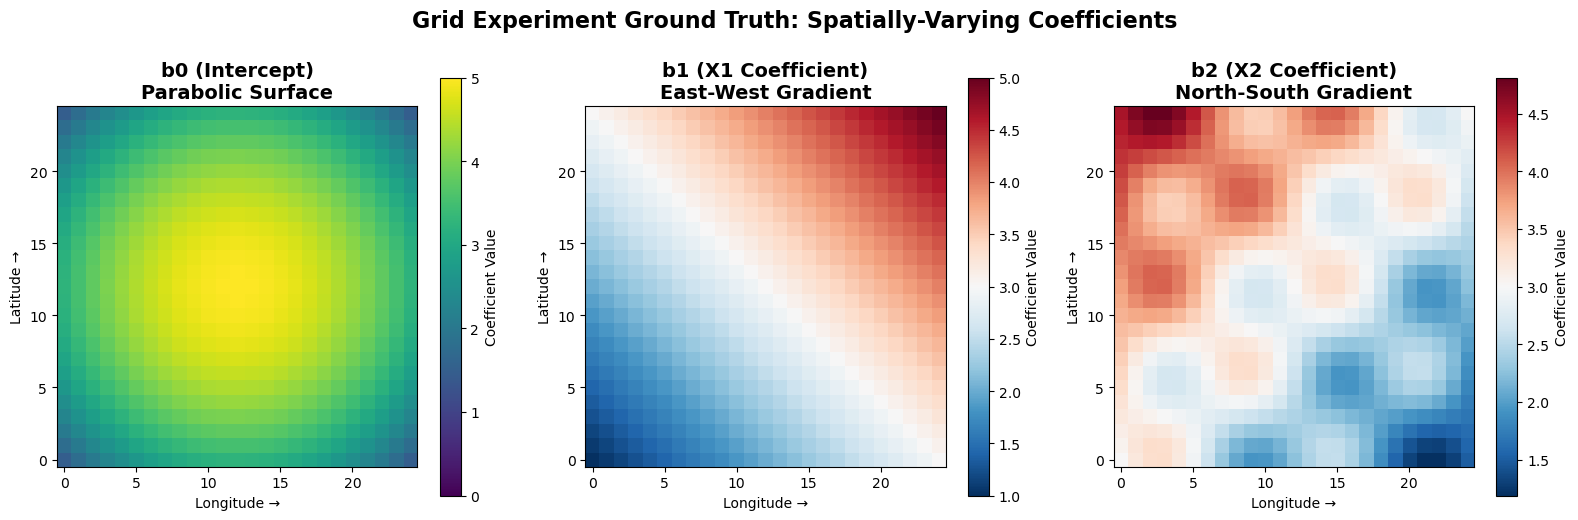


📊 Grid coefficients visualized


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# b0 (intercept) - parabolic surface
im0 = axes[0].imshow(b0_grid, cmap='viridis', vmin=0, vmax=5, origin='lower')
axes[0].set_title('b0 (Intercept)\nParabolic Surface', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude →')
axes[0].set_ylabel('Latitude →')
plt.colorbar(im0, ax=axes[0], label='Coefficient Value')

# b1 (X1 coefficient) - east-west gradient
im1 = axes[1].imshow(b1_grid, cmap='RdBu_r', origin='lower')
axes[1].set_title('b1 (X1 Coefficient)\nEast-West Gradient', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude →')
axes[1].set_ylabel('Latitude →')
plt.colorbar(im1, ax=axes[1], label='Coefficient Value')

# b2 (X2 coefficient) - north-south gradient
im2 = axes[2].imshow(b2_grid, cmap='RdBu_r', origin='lower')
axes[2].set_title('b2 (X2 Coefficient)\nNorth-South Gradient', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Longitude →')
axes[2].set_ylabel('Latitude →')
plt.colorbar(im2, ax=axes[2], label='Coefficient Value')

plt.suptitle('Grid Experiment Ground Truth: Spatially-Varying Coefficients', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Grid coefficients visualized")

## 4. Generate County Experiment Ground Truth

Generate ground truth for US counties using the same formulaic DGP applied to county centroids.

In [9]:
# Generate county data (same parameters as countiesRun.py)
print("Generating county data with formulaic DGP...")
county_data, county_extent, counties_gdf = create_county_data(
    noise_std=noise_std,
    random_seed=random_seed
)

print(f"✓ County data generated: {len(county_data)} counties")
print(f"  Extent: lon [{county_extent[0]:.2f}, {county_extent[1]:.2f}], lat [{county_extent[2]:.2f}, {county_extent[3]:.2f}]")
print(f"  b0 range: [{county_data['b0'].min():.3f}, {county_data['b0'].max():.3f}]")
print(f"  b1 range: [{county_data['b1'].min():.3f}, {county_data['b1'].max():.3f}]")
print(f"  b2 range: [{county_data['b2'].min():.3f}, {county_data['b2'].max():.3f}]")

# Merge ground truth with geometries for mapping
counties_gdf = counties_gdf.merge(county_data[['GEOID', 'b0', 'b1', 'b2']], on='GEOID', how='left')

Generating county data with formulaic DGP...
✓ County data generated: 3107 counties
  Extent: lon [-124.16, -67.63], lat [25.32, 48.83]
  b0 range: [1.718, 5.000]
  b1 range: [1.919, 4.781]
  b2 range: [1.732, 4.794]


## 5. Visualize County Ground Truth (Choropleth Maps)

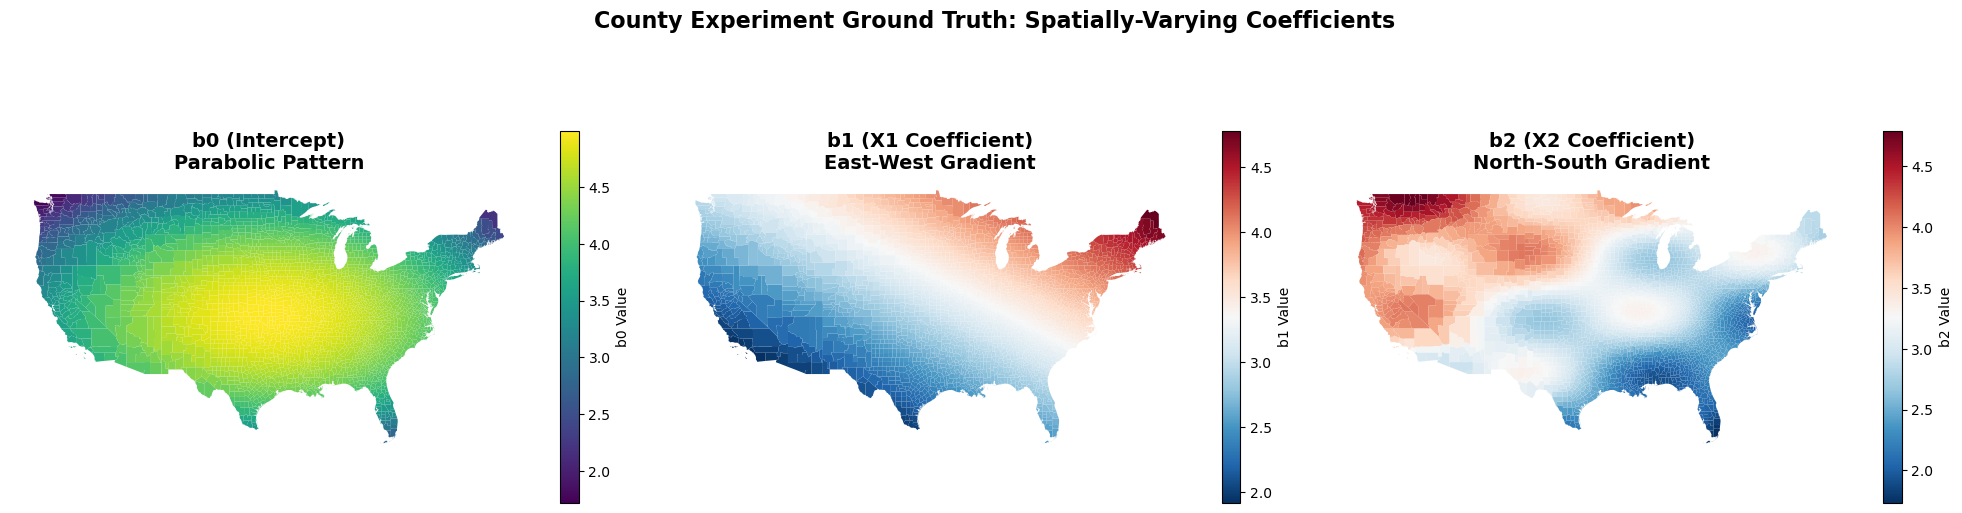


📊 County coefficients visualized


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# b0 (intercept)
counties_gdf.plot(
    column='b0',
    ax=axes[0],
    cmap='viridis',
    legend=True,
    legend_kwds={'label': 'b0 Value', 'shrink': 0.7}
)
axes[0].set_title('b0 (Intercept)\nParabolic Pattern', fontsize=14, fontweight='bold')
axes[0].axis('off')

# b1 (X1 coefficient)
counties_gdf.plot(
    column='b1',
    ax=axes[1],
    cmap='RdBu_r',
    legend=True,
    legend_kwds={'label': 'b1 Value', 'shrink': 0.7}
)
axes[1].set_title('b1 (X1 Coefficient)\nEast-West Gradient', fontsize=14, fontweight='bold')
axes[1].axis('off')

# b2 (X2 coefficient)
counties_gdf.plot(
    column='b2',
    ax=axes[2],
    cmap='RdBu_r',
    legend=True,
    legend_kwds={'label': 'b2 Value', 'shrink': 0.7}
)
axes[2].set_title('b2 (X2 Coefficient)\nNorth-South Gradient', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.suptitle('County Experiment Ground Truth: Spatially-Varying Coefficients', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n📊 County coefficients visualized")

## 6. Summary: What the Models Are Learning

The formulaic DGP creates three spatially-varying coefficients:

- **b0 (Intercept)**: Parabolic surface centered in the region
  - High in the center, lower at edges
  - Range: ~0 to 5
  
- **b1 (X1 Coefficient)**: East-to-west gradient
  - Changes linearly from west to east
  - Creates spatial heterogeneity in how X1 affects the outcome
  
- **b2 (X2 Coefficient)**: North-to-south gradient
  - Changes linearly from south to north
  - Creates spatial heterogeneity in how X2 affects the outcome

**The Challenge**: Location encoders must learn to represent these spatial patterns so that when combined with X1 and X2 features, the model can recover these spatially-varying coefficients through GeoShapley attribution.